# Large datasets

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/large_data.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/large_data.ipynb)

Since `fit` only stores the context, the cost of a foundation model is
paid at prediction time, and it grows with the number of context rows. In
this tutorial, we measure how the accuracy and the cost of the default model
grow with the size of the context on a dataset of about 46,000 rows, and
then go through the parameters that bound the cost: `chunk_size`,
`kv_cache`, `n_estimators` and `bag_size`. The
[Scaling and performance](https://lazy-tfm.readthedocs.io/en/latest/guide/scaling.html)
page of the User guide describes each of them in more detail.

## Setup

On Google Colab, the cell below installs the package with the TabPFN
backend. Elsewhere, install it first with `pip install 'lazy-tfm[tabpfn]'`.
Every timing below depends on the GPU, so the numbers on a Colab T4 will
differ from the ones shown here, while the trends should not.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn]'
    pass

In [2]:
import time  # Wall-clock timing

import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables
import torch  # Only to read the GPU's peak memory

import lazy
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 299792458  # One seed for everything random

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

We use the `protein` dataset (see
[Demo datasets](https://lazy-tfm.readthedocs.io/en/latest/guide/datasets.html)),
in which the target is the root-mean-square deviation (RMSD) of a predicted
protein structure from the true one, in ångströms, given nine
physicochemical properties of the structure. We hold out a random 2,000
rows as the test set and keep the remaining rows as the pool from which
we draw contexts of increasing size. All densities are written on one grid
of 420 bins over the range of the target, so that every model is scored in
the same way.

In [3]:
data = datasets.load_dataset("protein")
X, y = data.X, data.y

rng = np.random.default_rng(SEED)
order = rng.permutation(len(y))
test, pool = order[:2_000], order[2_000:]
X_test, y_test = X.iloc[test], y[test]

grid = lazy.Grid.linear(0.0, 21.0, 420)  # RMSD in [Å]
print(f"{len(pool):,} rows to draw contexts from, {len(test):,} test rows")
X.head()

43,730 rows to draw contexts from, 2,000 test rows


,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147


We score the densities with the continuous ranked probability score
(CRPS), which is the squared distance between the predicted cumulative
distribution and a step at the true value, integrated over the target. It
is in the units of the target (ångströms here), it reduces to the absolute
error for a point prediction, and lower is better. The helper below fits a
model on the first `n` rows of the pool, predicts the test set, and records
the CRPS, the wall-clock time of `fit` and `predict_proba` together, and the
peak GPU memory.

In [4]:
GPU = torch.cuda.is_available()


def run(
    n_context: int, label: str, **params: object
) -> tuple[dict, np.ndarray]:
    """Fits on n_context pool rows, predicts the test set and scores it."""
    rows = pool[:n_context]
    if GPU:
        torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()
    model = lazy.LazyModel(random_state=SEED, progress=False, **params)
    model.fit(X.iloc[rows], y[rows])
    pdfs = model.predict_proba(X_test, grid)
    seconds = time.perf_counter() - start
    memory = torch.cuda.max_memory_allocated() / 1e9 if GPU else np.nan
    row = {
        "setting": label,
        "context rows": n_context,
        "CRPS [Å]": metrics.crps(y_test, grid, pdfs),
        "time [s]": seconds,
        "peak GPU memory [GB]": memory,
    }
    return row, pdfs


# The first call loads the weights (and downloads them the first time), so we
# run it once on a small context to keep that cost out of the timings.
_ = run(1_000, "warm-up")

## Accuracy and cost against the context size

We first fit the default model, TabPFN-3.5 with 8 ensemble members, on
contexts of 1,000, 4,000 and 16,000 rows and on the whole pool.

In [5]:
sizes = [1_000, 4_000, 16_000, len(pool)]
results = [run(n, "default") for n in sizes]
scan = pd.DataFrame([row for row, _ in results])
full, pdfs_full = results[-1]
scan.round(3)

,setting,context rows,CRPS [Å],time [s],peak GPU memory [GB]
0,default,1000,1.871,1.623,1.518
1,default,4000,1.449,2.103,1.668
2,default,16000,1.185,8.746,2.275
3,default,43730,0.967,30.596,4.339


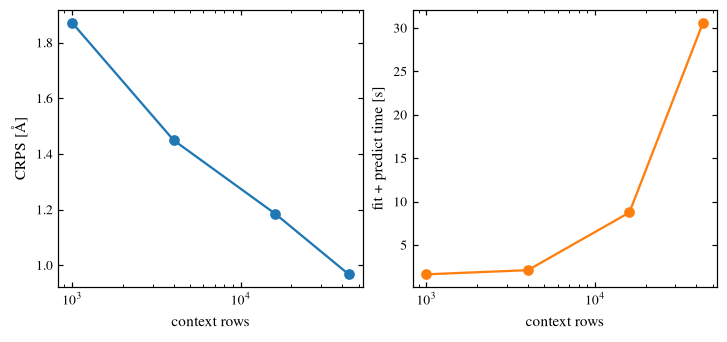

In [6]:
fig, (ax_crps, ax_time) = plt.subplots(
    1, 2, figsize=(6.5, 3), layout="constrained"
)
ax_crps.plot(scan["context rows"], scan["CRPS [Å]"], "o-")
ax_crps.set_ylabel("CRPS [Å]")
ax_time.plot(scan["context rows"], scan["time [s]"], "o-", color="C1")
ax_time.set_ylabel("fit + predict time [s]")
for ax in (ax_crps, ax_time):
    ax.set_xscale("log")
    ax.set_xlabel("context rows")

The figure shows the CRPS on the test set (left) and the time taken to fit
the model and predict the test set (right) against the number of context
rows. We see that the CRPS falls at every step as the context grows, from
1.871 Å on 1,000 rows to 0.967 Å on the full pool of 43,730 rows, so on this
dataset the extra context keeps improving the densities. However, the time
grows with the context as well, since the model processes the whole context
in every member and every test row attends to every context row. Therefore,
the full context is both the most accurate and the most expensive choice.
The timings come from a single run each and vary from run to run (more so
on a GPU shared with other jobs), so we read them for their trend rather
than their exact values.

## Memory: `chunk_size`

The model predicts the test rows `chunk_size` rows at a time (8,192 by
default), which bounds the peak memory of a prediction. Since a row's
answer never depends on which other rows share its chunk, a smaller chunk
changes the answers only by floating-point rounding. To keep this tutorial
quick, we use the context of 16,000 rows from here on, and predict the test
set again in chunks of 500 rows, with and without the key/value cache
(described below), and compare the densities with those of one pass.

In [7]:
mid, pdfs_mid = results[2]
chunked, pdfs_chunked = run(16_000, "chunk_size=500", chunk_size=500)
uncached, _ = run(
    16_000, "chunk_size=500, kv_cache=False", chunk_size=500, kv_cache=False
)
knobs = pd.DataFrame([mid, chunked, uncached])
diff = np.max(np.abs(pdfs_chunked - pdfs_mid)) / np.max(pdfs_mid)
print(f"Largest change in any density: {diff:.1e} of the largest density")
knobs.round(3)

Largest change in any density: 2.1e-07 of the largest density


,setting,context rows,CRPS [Å],time [s],peak GPU memory [GB]
0,default,16000,1.185,8.746,2.275
1,chunk_size=500,16000,1.185,8.597,2.194
2,"chunk_size=500, kv_cache=False",16000,1.185,30.362,2.292


The table shows that the CRPS is the same to the digits shown in all three
rows, and the printed difference between the densities of one pass and of
small chunks is at the level of floating-point rounding.
The smaller chunks lower the peak memory only a little here, since with
2,000 test rows the memory is dominated by the context rather than by the
queries, and `chunk_size` matters most when many rows are predicted at once.

The third row turns off the key/value cache. With `kv_cache=True` (the
default), the model processes the context once at `fit`, stores the result,
and each chunk of queries only attends to what was stored. With
`kv_cache=False`, the context is processed again for every chunk, here
four times, which takes much longer but needs the least memory of the
three. Therefore, we keep the cache whenever it fits, and turning it off
is a way to fit a large context on a small GPU.

## Ensemble members: `n_estimators`

Each of the `n_estimators` members sees the context with its own feature
transforms and column order, and the density is their average. The cost
grows roughly linearly with the number of members, so fewer members are the
simplest way to save time. We compare 1, 2, 4 and 8 members on a context of
16,000 rows.

In [8]:
members = pd.DataFrame(
    [run(16_000, f"n_estimators={k}", n_estimators=k)[0] for k in (1, 2, 4)]
    + [mid]
)
members.round(3)

,setting,context rows,CRPS [Å],time [s],peak GPU memory [GB]
0,n_estimators=1,16000,1.190,1.573,2.351
1,n_estimators=2,16000,1.186,2.707,2.492
2,n_estimators=4,16000,1.186,4.062,2.735
3,default,16000,1.185,8.746,2.275


The table shows that the time and the memory grow with the number of
members, while the CRPS changes very little between 1 and 8 members on this
dataset. Therefore, fewer members are a reasonable trade when time is short,
although on other datasets the ensemble can matter more, and we suggest
checking it on a held-out set before settling on a small one.

## Bagging: `bag_size`

With `bag_size`, each member sees its own random subset of the context
instead of all of it, so that the members together cover most of the rows
while each attends to fewer of them. We give each of the 8 members a bag of
10,000 rows drawn from the full pool and compare it with the full context.

In [9]:
bagged, _ = run(len(pool), "bag_size=10000", bag_size=10_000)
bagging = pd.DataFrame([full, bagged, mid])
bagging.round(3)

,setting,context rows,CRPS [Å],time [s],peak GPU memory [GB]
0,default,43730,0.967,30.596,4.339
1,bag_size=10000,43730,1.179,8.487,2.778
2,default,16000,1.185,8.746,2.275


The table compares the full context (first row) with the bagged ensemble
(second row) and, for reference, the unbagged model on 16,000 rows (third
row). We see that the bagged ensemble takes less than a third of the time
and less than half of the peak GPU memory of the full context, since each
member attends to only 10,000 rows. However, it scores close to the model on
16,000 rows and clearly worse than the full context, although its members
together saw most of the pool. For TabPFN-3.5, which was pretrained on
contexts of up to a million rows, a single full context is therefore the
more accurate choice whenever it fits in time and memory, and bagging is a
way to bound the time and memory of each member when it does not.

For other models, bagging is needed. LimiX-2 degrades above about 20,000
context rows (and `lazy` warns with a `ContextSizeWarning` when it receives
a larger context without bagging), while TabPFN-2 was pretrained on at most
10,000 rows and refuses a larger context without bagging. Since TabPFN checks
this limit on each member's bag, bagging within the limit lets TabPFN-2 use a
larger context. For both, we keep each bag within the limit and use enough
members to cover the context, as in our own tests:

```python
model = lazy.LazyModel("limix", bag_size=20_000, n_estimators=32)
```

[Limits and pitfalls](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html)
gives the context limits of every model.

## Much larger datasets

The full context of the `year` dataset (515,345 rows, 90 features) is out of
reach on a T4 within a few minutes, so we do not run it here. Since the time
grows with the context, the number of members and the number of features,
the parameters above combine, and a reasonable start is a few members, each
with a bag of tens of thousands of rows, a moderate `chunk_size` and the
cache left on:

```python
X, y = datasets.load_dataset("year", return_X_y=True)
model = lazy.LazyModel(bag_size=20_000, n_estimators=4, chunk_size=2_048)
```

Finally, every model chooses its device at `fit`, and most of them need a
GPU to be practical at these sizes (TabPFN-3.5 refuses more than 5,000
context rows per member on a CPU), while TabICL runs nearly as fast on a CPU
as on a GPU.

For the next steps, we suggest the following pages:

- [Scaling and performance](https://lazy-tfm.readthedocs.io/en/latest/guide/scaling.html):
  the measured cost of every model and what each parameter does.
- [Choosing a model](https://lazy-tfm.readthedocs.io/en/latest/guide/choosing.html):
  which model to use for a given dataset and hardware.
- [Reproducibility](https://lazy-tfm.readthedocs.io/en/latest/guide/reproducibility.html):
  why chunking does not change the answers.